# Кластеризация листингов Airbnb (Париж)

На рынке очень много объявлений, руками их не разобрать. Решили сгруппировать похожие листинги в несколько сегментов, чтобы видеть структуру предложения: кто с кем конкурирует, где объекты простаивают, чем отличаются профессионалы от частников.


In [1]:
import json
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, SpectralClustering, HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import BallTree

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Данные

Набор: около 39 тысяч объявлений в Парижу. Дополнительно есть файл со станциями метро 1308 штук — по нему посчитаем близость к метро, это важный фактор для аренды. В париже метро реально связывает разные районы города и является важным критерием.

In [2]:
df = pd.read_csv("new data/data (3).csv")
df = df.drop(columns=["Unnamed: 0"])  #индекс 
print(df.shape)
df.head(3)

(38976, 57)


,name,description,neighborhood_overview,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,...,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,host_verifications_email,host_verifications_phone,host_verifications_work_email,host_age_on_platform
0,"Marais - Charming loft, river view","In the heart of historical Paris le Marais, gr...",Le Marais is the heart of Paris. Few years ago...,"Paris, France","I travel a lot for work and when I'm away, my ...",3,1.0,0.92,True,Saint-Paul - Ile Saint-Louis,...,False,1,1,0,0,0.66,True,True,False,11.446575
1,"Cozy place, Sacré Coeur Montmartre in the SoPi",Cozy apartment close to everything.<br />Perfe...,One of the most trendy corners of the capital ...,"Paris, France","Jeune ingénieur, je propose mon appartement à ...",1,1.0,0.89,False,Pigalle - Saint-Georges,...,False,1,1,0,0,0.72,True,True,False,12.172603
2,Prestige on the Louvre & Tuileries,Experience luxury on the 6th floor with elevat...,"With a setting right in the heart of Paris, ma...","Paris, France","Passionné d'art et styliste de profession, je ...",1,1.0,0.98,True,Louvre - Tuileries,...,False,1,1,0,0,2.71,True,True,False,11.482192


## Беглый EDA

Смотрим пропуски, распределении основных полей, географию, корреляции, чтобы понять с чем работаем.

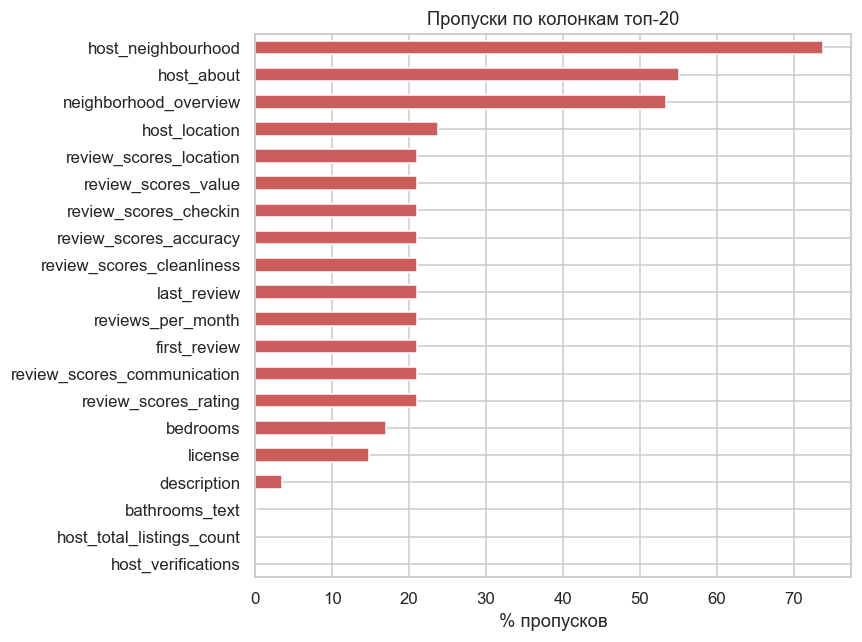

host_neighbourhood             73.8
host_about                     55.0
neighborhood_overview          53.3
host_location                  23.8
review_scores_location         21.0
review_scores_value            21.0
review_scores_checkin          21.0
review_scores_accuracy         21.0
review_scores_cleanliness      21.0
last_review                    21.0
reviews_per_month              21.0
first_review                   21.0
review_scores_communication    21.0
review_scores_rating           21.0
bedrooms                       17.0
license                        14.8
description                     3.4
bathrooms_text                  0.1
host_total_listings_count       0.0
host_verifications              0.0
dtype: float64

In [3]:
#доля пропусков по колонка. рисуем только те, где они есть
miss = (df.isna().mean() * 100).sort_values(ascending=False)
top_miss = miss[miss > 0].head(20)

plt.figure(figsize=(8, 6))
top_miss.iloc[::-1].plot.barh(color="indianred")
plt.xlabel("% пропусков")
plt.title("Пропуски по колонкам топ-20")
plt.tight_layout()

plt.show()

top_miss.round(1)

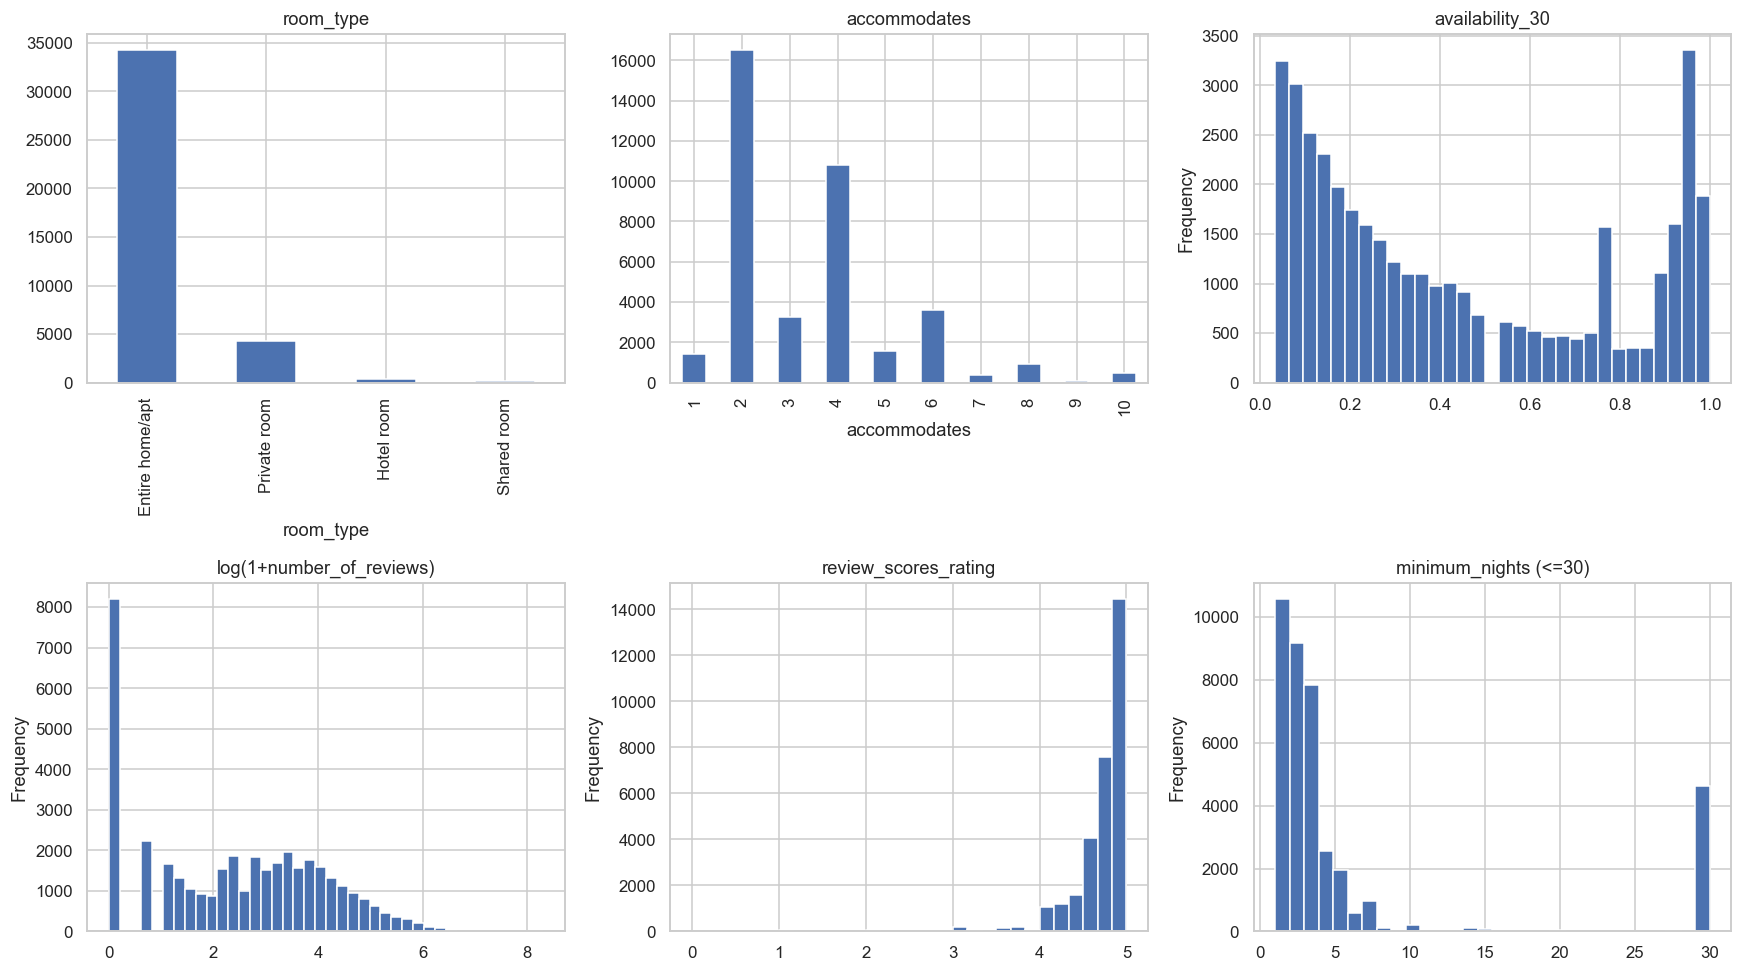

In [5]:
#распределение ключевых признаков
fig, ax = plt.subplots(2, 3, figsize=(16, 9))

df["room_type"].value_counts().plot.bar(ax=ax[0, 0], title="room_type")
df["accommodates"].clip(upper=10).value_counts().sort_index().plot.bar(ax=ax[0, 1], title="accommodates")
df["availability_30"].plot.hist(bins=31, ax=ax[0, 2], title="availability_30")

#лог
np.log1p(df["number_of_reviews"]).plot.hist(bins=40, ax=ax[1, 0], title="log(1+number_of_reviews)")
df["review_scores_rating"].dropna().plot.hist(bins=30, ax=ax[1, 1], title="review_scores_rating")
df["minimum_nights"].clip(upper=30).plot.hist(bins=30, ax=ax[1, 2], title="minimum_nights (<=30)")

plt.tight_layout()

plt.show()

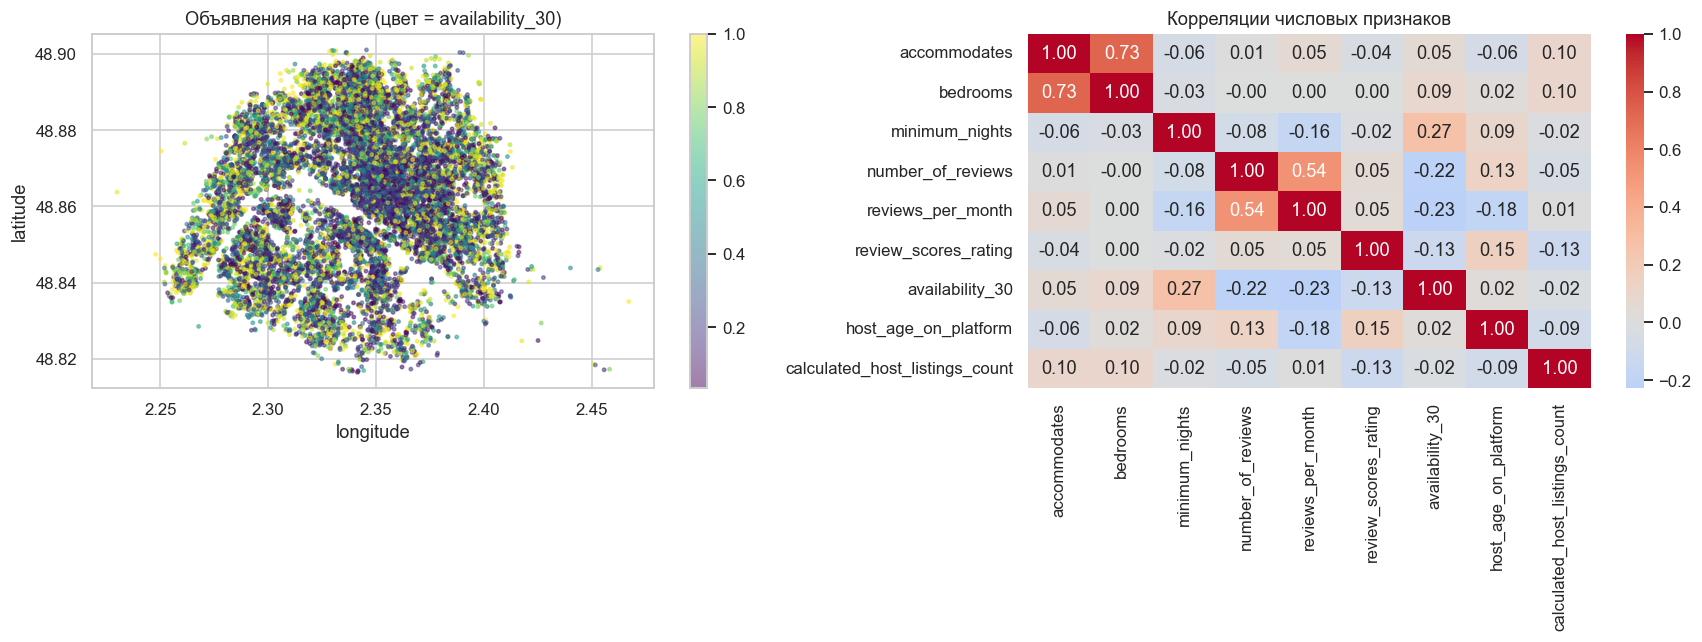

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

#карта Парижа каждая точка объявление, цвет это доступность
sample = df.sample(15000, random_state=RANDOM_STATE)
sc = ax[0].scatter(sample["longitude"], sample["latitude"],
                   c=sample["availability_30"], s=5, cmap="viridis", alpha=0.5)
ax[0].set_title("Объявления на карте (цвет = availability_30)")
ax[0].set_xlabel("longitude")
ax[0].set_ylabel("latitude")
plt.colorbar(sc, ax=ax[0])

#смотрю нет ли явных дублей
num_cols = ["accommodates", "bedrooms", "minimum_nights", "number_of_reviews",
            "reviews_per_month", "review_scores_rating", "availability_30",
            "host_age_on_platform", "calculated_host_listings_count"]
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax[1])
ax[1].set_title("Корреляции числовых признаков")

plt.tight_layout()
plt.show()

## Готовим признаки

Часть полей в формате текста, значит их надо распарсить:

- `amenities` это JSON-список удобств значит считаем количество и делаем флаги на нужные (кондей, лифт, стиралка и т.д.)
- `bathrooms_text` достаём число ванных и флаг совмещённой
- `license` схлопываем в 4 категории (нет / mobility lease / exempt / зарегистрирована)
- по хосту профессионал он или нет, сколько способов верификации
- `property_type` имеет 61 значение, оставляем топ-6 + other

In [7]:
def parse_amenities(x):
    try:
        return [a.strip() for a in json.loads(x)]
    except Exception:
        return []

#отдельные флаги
AMEN_KEYWORDS = {
    "amen_ac": ["air conditioning"],
    "amen_elevator": ["elevator"],
    "amen_washer": ["washer"],
    "amen_dishwasher": ["dishwasher"],
    "amen_tv": ["tv"],
    "amen_self_checkin": ["self check-in"],
    "amen_parking": ["parking"],
    "amen_pets": ["pets allowed"],
    "amen_longterm": ["long term stays"],
    "amen_pool": ["pool"],
    "amen_gym": ["gym"],
    "amen_workspace": ["dedicated workspace", "workspace"],
    "amen_kitchen": ["kitchen"],
    "amen_balcony": ["balcony", "patio"],
}

def amen_features(items):
    low = [a.lower() for a in items]
    txt = " | ".join(low)
    feats = {"amen_count": len(items)}
    for name, kws in AMEN_KEYWORDS.items():
        feats[name] = int(any(k in txt for k in kws))
    #отдельно сушилка для белья, чтобы не перепутать с феном, как оказалось это достаточно просто)))
    feats["amen_dryer"] = int(any("dryer" in a and "hair" not in a for a in low))
    return feats

def parse_bathrooms(t):
    #примеры
    if pd.isna(t):
        return pd.Series({"n_bathrooms": np.nan, "bath_shared": 0})
    tl = str(t).lower()
    shared = int("shared" in tl)
    if "half" in tl:
        return pd.Series({"n_bathrooms": 0.5, "bath_shared": shared})
    m = re.search(r"([0-9]*\.?[0-9]+)", tl)
    n = float(m.group(1)) if m else np.nan
    return pd.Series({"n_bathrooms": n, "bath_shared": shared})

def license_category(x):
    #лицензии
    if pd.isna(x) or str(x).strip() in ("None", ""):
        return "none"
    xs = str(x).lower()
    if "mobility" in xs or "bail" in xs:
        return "mobility_lease"
    if "exempt" in xs:
        return "exempt"
    if any(ch.isdigit() for ch in xs):
        return "registered"
    return "other" 

In [8]:
fe = df.copy()

#раскладываем amenities и bathrooms по отдельным колонкам
amen = fe["amenities"].apply(parse_amenities).apply(amen_features).apply(pd.Series)
bath = fe["bathrooms_text"].apply(parse_bathrooms)
fe = pd.concat([fe, amen, bath], axis=1)

fe["license_cat"] = fe["license"].apply(license_category)
#профи считаем если у хоста больше одного объекта
fe["host_prof"] = (fe["calculated_host_listings_count"] > 1).astype(int)
fe["host_verif_count"] = fe[["host_verifications_email", "host_verifications_phone",
                              "host_verifications_work_email"]].sum(axis=1)

#property_type слишком дробный, оставляем только частые категории
top_prop = fe["property_type"].value_counts().head(6).index
fe["property_group"] = np.where(fe["property_type"].isin(top_prop), fe["property_type"], "Other")

#0/1
for c in ["host_is_superhost", "host_identity_verified", "instant_bookable"]:
    fe[c] = fe[c].astype(int)

fe[["amen_count", "n_bathrooms", "bath_shared", "license_cat", "host_prof",
    "host_verif_count", "property_group"]].head()

,amen_count,n_bathrooms,bath_shared,license_cat,host_prof,host_verif_count,property_group
0,27,1.0,0.0,registered,0,2,Entire rental unit
1,32,1.0,0.0,registered,0,2,Entire rental unit
2,66,2.0,0.0,exempt,0,2,Entire rental unit
3,42,1.0,0.0,registered,0,2,Entire rental unit
4,42,1.0,0.0,registered,1,2,Entire rental unit


### Близость к метро/RER

Для каждого объявления считаем расстояние до ближайшей станции и смотрим сколько станций в радиусе 500 м. Чтобы не прогонять 39к x 1308 пар в лоб, используем `BallTree` с метрикой haversine (единственный нюанс то, что она работает в радианах, поэтому на выходе переводим в метры).

In [9]:
stations = pd.read_csv("new data/metro_rer_idf.csv")

#дерево по координатам станций
tree = BallTree(np.radians(stations[["latitude", "longitude"]].values), metric="haversine")
coords = np.radians(fe[["latitude", "longitude"]].values)

EARTH_M = 6_371_000  #радиус Земли в метрах из википедии
#расстояние до ближайшей станции
dist, _ = tree.query(coords, k=1)
fe["dist_metro_m"] = dist[:, 0] * EARTH_M
#сколько станций в пешей доступности в радиусе 500 метров
fe["metro_within_500m"] = tree.query_radius(coords, r=500 / EARTH_M, count_only=True)

fe[["dist_metro_m", "metro_within_500m"]].describe().round(1)

,dist_metro_m,metro_within_500m
count,38976.0,38976.0
mean,230.9,6.0
std,121.0,5.1
min,1.2,0.0
25%,146.4,3.0
50%,212.6,5.0
75%,297.1,8.0
max,2504.0,44.0


In [10]:
#PowerTransformer
num_skewed = ["amen_count", "minimum_nights", "maximum_nights",
              "calculated_host_listings_count", "host_total_listings_count",
              "dist_metro_m", "metro_within_500m"]
#стандартизация
num_normal = ["accommodates", "bedrooms", "n_bathrooms", "review_scores_rating",
              "host_age_on_platform", "host_response_rate", "host_acceptance_rate",
              "latitude", "longitude", "host_verif_count"]
#0/1
binary = ["bath_shared", "host_is_superhost", "host_identity_verified", "instant_bookable",
          "host_prof", "amen_ac", "amen_elevator", "amen_washer", "amen_dryer",
          "amen_dishwasher", "amen_tv", "amen_self_checkin", "amen_parking", "amen_pets",
          "amen_longterm", "amen_pool", "amen_gym", "amen_workspace", "amen_kitchen", "amen_balcony"]
categorical = ["room_type", "property_group", "license_cat"]

features = num_skewed + num_normal + binary + categorical
X_raw = fe[features].copy()
print("всего признаков:", len(features))

всего признаков: 40


## Препроцессинг

Собираем всё в один `ColumnTransformer`, чтобы препроцессинг был воспроизводимым и его можно было применить к новым данным:

- скошенные числовые обрабатываем через `PowerTransformer`, обычная стандартизация их не вытянетт
- обычные числовые просто стандартизируем (`StandardScaler`)
- категориальные кодируем `OneHotEncoder`
- пропуски заполняем медианой 

In [11]:
#для скошенных
skewed_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("pow", PowerTransformer(method="yeo-johnson", standardize=True)),
])
#для обычных числовых
normal_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("sc", StandardScaler()),
])
#0/1
binary_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
])
#категориальные
cat_pipe = Pipeline([
    ("imp", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer([
    ("skew", skewed_pipe, num_skewed),
    ("norm", normal_pipe, num_normal),
    ("bin", binary_pipe, binary),
    ("cat", cat_pipe, categorical),
])

X = preprocess.fit_transform(X_raw)
print("матрица после препроцессинга:", X.shape)

матрица после препроцессинга: (38976, 52)


## PCA

После one-hot признаков становится много и они скоррелированы (например, типы комнат) PCA убирает эту избыточность и заодно ускоряет кластеризацию. Берём столько компонент, чтобы держать примерно 90% дисперсии.

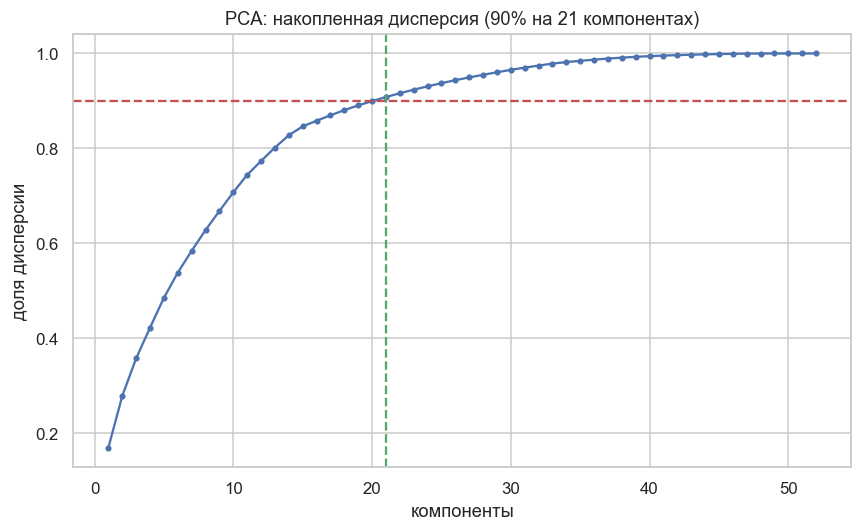

после PCA: (38976, 21)


In [ ]:
#сначала смотрим, сколько компонент нужно на 90% дисперсии
pca_full = PCA(random_state=RANDOM_STATE).fit(X)
cum = np.cumsum(pca_full.explained_variance_ratio_)
n90 = int(np.argmax(cum >= 0.90) + 1)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum) + 1), cum, marker="o", ms=3)
plt.axhline(0.9, color="r", ls="--")
plt.axvline(n90, color="g", ls="--")
plt.title(f"PCA: накопленная дисперсия (90% на {n90} компонентах)")
plt.xlabel("компоненты")
plt.ylabel("доля дисперсии")
plt.tight_layout()

plt.show()

N_COMP = max(n90, 10)
X_pca = PCA(n_components=N_COMP, random_state=RANDOM_STATE).fit_transform(X)
print("после PCA:", X_pca.shape)

## Сколько брать кластеров

Смотрим локоть по inertia и silhouette для k от 2 до 10.

Тут снова есть нюанс, на смешанных данных silhouette почти всегда тянет к k=2 это типа просто профи против всех остальных, для сегментации нам толку мало. Поэтому опираемся на локоть и на то, читаются ли кластеры по смыслу. На k=5 группы получаются разумные и различимые, на нём и отсановимся.

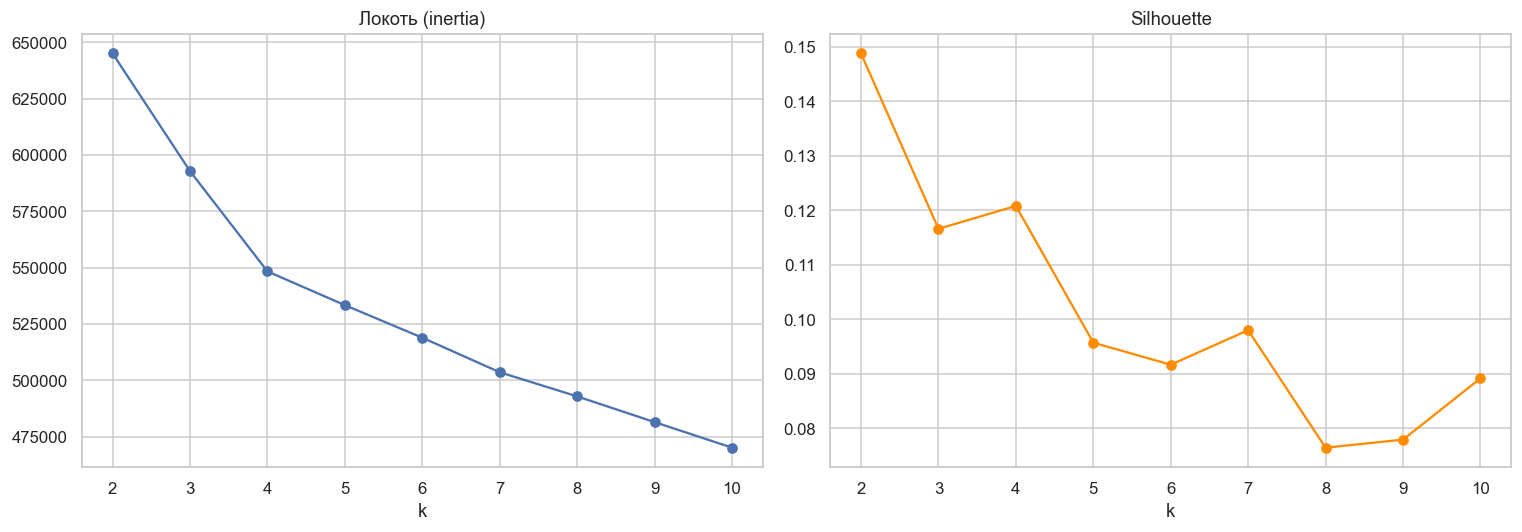

формальный максимум silhouette на k = 2
берём K = 5


In [ ]:
ks = range(2, 11)
inertia, sil = [], []
#silhouette на всех 80к считать долго, возьмем подвыборку
sidx = np.random.choice(len(X_pca), size=5000, replace=False)

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_pca)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_pca[sidx], km.labels_[sidx]))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(list(ks), inertia, marker="o")
ax[0].set_title("Локоть (inertia)")
ax[0].set_xlabel("k")
ax[1].plot(list(ks), sil, marker="o", color="darkorange")
ax[1].set_title("Silhouette")
ax[1].set_xlabel("k")
plt.tight_layout()

plt.show()

print("формальный максимум silhouette на k =", list(ks)[int(np.argmax(sil))])
K = 5  
print("берём K =", K)

## Сравним разные алгоритмы

Чтобы не брать KMeans вслепую, протестим несколько алгоритмов разной природы и сравним метрики. Считаем на общей подвыборке в 8к точек, иначе иерархическая и спектральная кластеризация слишком долгие.

- KMeans — делит по центроидам;
- GaussianMixture — вероятностный, через EM;
- Agglomerative (Ward) — иерархический;
- Spectral — строит граф соседей;
- HDBSCAN — по плотности, сам решает сколько кластеров и помечает шум.

Метрики: silhouette (больше лучше), Davies-Bouldin (меньше лучше), Calinski-Harabasz (больше лучше).

In [14]:
sample_n = 8000
samp = np.random.choice(len(X_pca), size=sample_n, replace=False)
Xs = X_pca[samp]

def eval_labels(Xm, labels):
    labels = np.asarray(labels)
    mask = labels != -1
    if len(set(labels[mask])) < 2:
        return (np.nan, np.nan, np.nan, int((~mask).sum()))
    return (
        silhouette_score(Xm[mask], labels[mask]),
        davies_bouldin_score(Xm[mask], labels[mask]),
        calinski_harabasz_score(Xm[mask], labels[mask]),
        int((~mask).sum()),
    )

models = {
    "KMeans": KMeans(n_clusters=K, n_init=10, random_state=RANDOM_STATE),
    "GaussianMixture": GaussianMixture(n_components=K, random_state=RANDOM_STATE),
    "Agglomerative(Ward)": AgglomerativeClustering(n_clusters=K, linkage="ward"),
    "Spectral": SpectralClustering(n_clusters=K, random_state=RANDOM_STATE,
                                   assign_labels="kmeans", affinity="nearest_neighbors"),
    "HDBSCAN": HDBSCAN(min_cluster_size=150),
}

rows = []
for name, model in models.items():
    lab = model.fit_predict(Xs)
    s, db, ch, noise = eval_labels(Xs, lab)
    rows.append({"model": name, "n_clusters": len(set(lab[lab != -1])),
                 "silhouette": s, "davies_bouldin": db,
                 "calinski_harabasz": ch, "noise": noise})

pd.DataFrame(rows).set_index("model").round(3)

,n_clusters,silhouette,davies_bouldin,calinski_harabasz,noise
model,,,,,
KMeans,5,0.120,2.336,827.764,0
GaussianMixture,5,0.031,3.908,433.650,0
Agglomerative(Ward),5,0.089,2.641,669.658,0
Spectral,5,0.066,2.159,444.109,0
HDBSCAN,0,NaN,NaN,NaN,8000


## Финальная модель

По метрикам лучше всех KMeans, плюс он простой и устойчивый знначит берём его. Учим на всех данных и описываем сегменты по исходным признакам (теперь уже добавляем сюда спрос: доступность и отзывы).

In [15]:
final = KMeans(n_clusters=K, n_init=20, random_state=RANDOM_STATE).fit(X_pca)
fe["cluster"] = final.labels_
print(fe["cluster"].value_counts().sort_index())

#средние по сегментам это то чем кластеры реально отличаются
profile_num = ["accommodates", "bedrooms", "n_bathrooms", "amen_count", "minimum_nights",
               "dist_metro_m", "review_scores_rating", "host_age_on_platform",
               "calculated_host_listings_count", "host_is_superhost", "host_prof",
               "instant_bookable", "availability_30", "number_of_reviews", "reviews_per_month"]
prof = fe.groupby("cluster")[profile_num].mean().round(2)
prof.insert(0, "size", fe["cluster"].value_counts().sort_index())
prof

cluster
0    10244
1     8675
2    11122
3     5073
4     3862
Name: count, dtype: int64


,size,accommodates,bedrooms,n_bathrooms,amen_count,minimum_nights,dist_metro_m,review_scores_rating,host_age_on_platform,calculated_host_listings_count,host_is_superhost,host_prof,instant_bookable,availability_30,number_of_reviews,reviews_per_month
cluster,,,,,,,,,,,,,,,,
0,10244,3.16,1.21,1.06,28.75,9.31,209.37,4.56,5.50,62.68,0.28,0.99,0.72,0.37,40.35,1.82
1,8675,3.11,1.41,1.11,17.42,56.54,246.95,4.69,8.17,1.45,0.01,0.09,0.10,0.77,7.33,0.45
2,11122,2.82,1.25,1.07,30.30,5.45,216.09,4.82,8.74,1.19,0.40,0.15,0.15,0.28,51.08,1.46
3,5073,3.02,1.30,1.10,31.65,7.01,287.76,4.78,7.35,1.49,0.37,0.22,0.21,0.35,44.88,1.52
4,3862,6.93,2.95,2.36,37.39,6.65,219.44,4.73,6.95,57.27,0.35,0.74,0.56,0.44,44.29,1.70


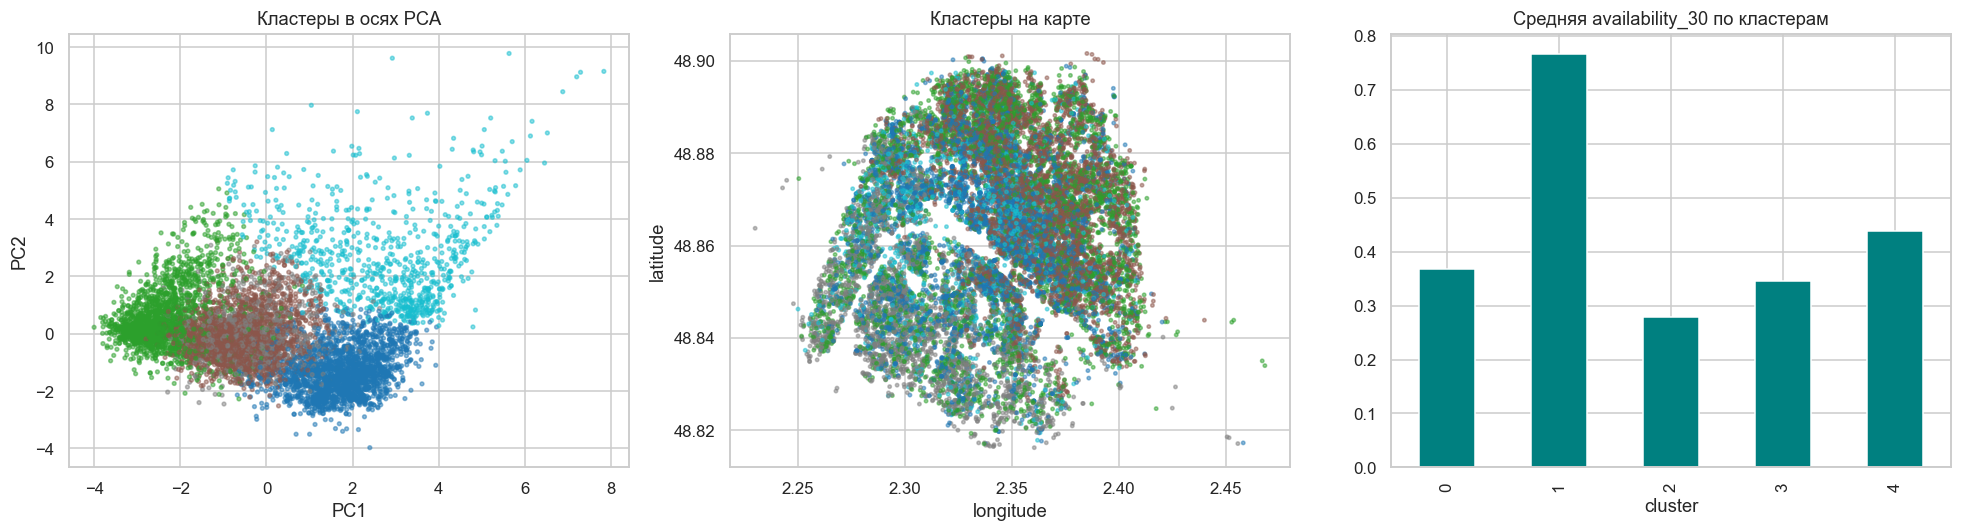

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

#как кластеры выглядят в первых двух компонентах PCA
Xv = X_pca[samp]
ax[0].scatter(Xv[:, 0], Xv[:, 1], c=final.labels_[samp], cmap="tab10", s=6, alpha=0.5)
ax[0].set_title("Кластеры в осях PCA")
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")

#как они же на карте города
gs = fe.sample(20000, random_state=RANDOM_STATE)
ax[1].scatter(gs["longitude"], gs["latitude"], c=gs["cluster"], cmap="tab10", s=5, alpha=0.5)
ax[1].set_title("Кластеры на карте")
ax[1].set_xlabel("longitude")
ax[1].set_ylabel("latitude")

#средняя доступность по кластерам (связка со второй задачей)
fe.groupby("cluster")["availability_30"].mean().plot.bar(ax=ax[2], color="teal")
ax[2].set_title("Средняя availability_30 по кластерам")
ax[2].set_xlabel("cluster")

plt.tight_layout()

plt.show()

In [17]:
#из чего состоят кластеры по типу жилья
pd.crosstab(fe["cluster"], fe["room_type"], normalize="index").round(2)

room_type,Entire home/apt,Hotel room,Private room,Shared room
cluster,,,,
0,0.81,0.03,0.15,0.01
1,0.91,0.00,0.09,0.00
2,0.88,0.00,0.11,0.00
3,0.87,0.00,0.13,0.00
4,0.98,0.00,0.02,0.00


In [18]:
def name_segment(r):
    #меняем названия на человекочитаемые
    if r["accommodates"] >= 5:
        return "Большие апартаменты (семьи/группы)"
    if r["minimum_nights"] >= 30:
        return "Длительная аренда (большой мин. срок, много свободных дней)"
    if r["host_prof"] >= 0.7 or r["calculated_host_listings_count"] >= 20:
        return "Профессиональные управляющие"
    #оставшиеся разделяем по близости к метро
    if r["dist_metro_m"] <= 250:
        return "Частное жильё у метро (центр)"
    return "Частное жильё подальше от метро"

seg_names = prof.apply(name_segment, axis=1)
fe["segment"] = fe["cluster"].map(seg_names)

summary = prof.copy()
summary.insert(0, "segment", seg_names)
summary[["segment", "size", "accommodates", "minimum_nights", "host_prof",
         "calculated_host_listings_count", "host_is_superhost", "availability_30",
         "reviews_per_month"]]

,segment,size,accommodates,minimum_nights,host_prof,calculated_host_listings_count,host_is_superhost,availability_30,reviews_per_month
cluster,,,,,,,,,
0,Профессиональные управляющие,10244,3.16,9.31,0.99,62.68,0.28,0.37,1.82
1,"Длительная аренда (большой мин. срок, много св...",8675,3.11,56.54,0.09,1.45,0.01,0.77,0.45
2,Частное жильё у метро (центр),11122,2.82,5.45,0.15,1.19,0.40,0.28,1.46
3,Частное жильё подальше от метро,5073,3.02,7.01,0.22,1.49,0.37,0.35,1.52
4,Большие апартаменты (семьи/группы),3862,6.93,6.65,0.74,57.27,0.35,0.44,1.70


## Что получилось

Рынок раскладывается на 5 понятных групп:

- **Частное жильё у метро (центр)** — частники с высоким рейтингом, рядом много станций, бронируются лучше всех (самая низкая availability).
- **Частное жильё подальше от метро** — похожее по качеству, но дальше от транспорта (этот сегмент выделился именно благодаря фиче близости к метро).
- **Профессиональные управляющие** — мульти-листинг, instant booking включён, но рейтинг ниже остальных.
- **Длительная аренда** — большой минимальный срок и много свободных дней, мало отзывов — отдельная бизнес-модель.
- **Большие апартаменты** — вместимость 6+, много спален и удобств, под семьи и группы.

Добавление расстояния до метро заметно повлияло: среди качественного частного жилья появилось разделение на центральное (рядом с транспортом) и более периферийное.

Как это можно использовать: сравнивать объект с похожими внутри его сегмента, подсказывать частникам как дорасти до суперхоста, а сегмент отдавать как признак во вторую задачу — предсказание `availability_30`.

Сохраним размеченные данные, чтобы переиспользовать.

In [19]:
fe.to_parquet("listings_with_clusters.parquet", index=False)
print("сохранили listings_with_clusters.parquet", fe.shape)
print(fe["segment"].value_counts())

сохранили listings_with_clusters.parquet (38976, 83)
segment
Частное жильё у метро (центр)                                  11122
Профессиональные управляющие                                   10244
Длительная аренда (большой мин. срок, много свободных дней)     8675
Частное жильё подальше от метро                                 5073
Большие апартаменты (семьи/группы)                              3862
Name: count, dtype: int64
